模型准确率: 1.0000 (100.00%)


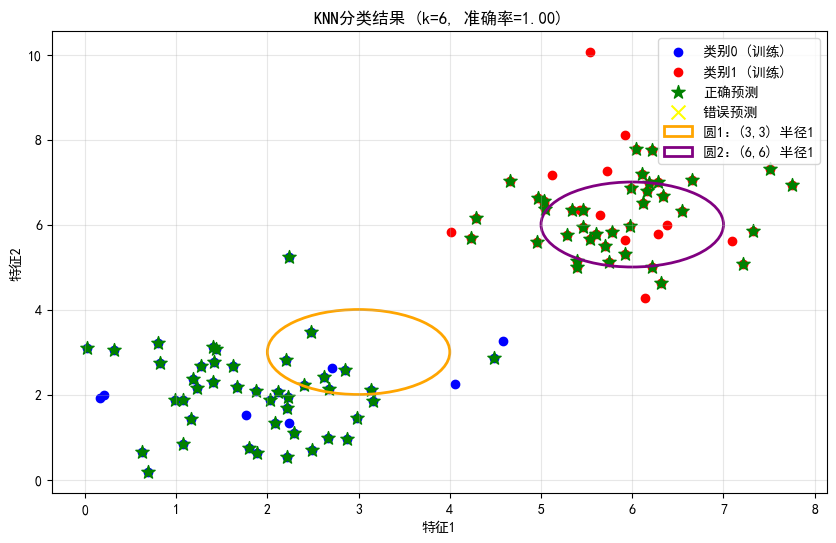

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams["font.family"] = ["SimHei"]  # 优先使用SimHei
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

class KNN:
    """K近邻算法的原生实现"""
    
    def __init__(self, k=3, distance_metric='euclidean'):
        """
        初始化KNN模型
        
        参数:
            k: 近邻数量
            distance_metric: 距离度量方式，支持'euclidean'(欧氏距离)和'manhattan'(曼哈顿距离)
        """
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        """
        训练模型（KNN是惰性学习，这里只是存储训练数据）
        
        参数:
            X: 训练特征数据，形状为(n_samples, n_features)
            y: 训练标签数据，形状为(n_samples,)
        """
        self.X_train = X
        self.y_train = y
    
    def _calculate_distance(self, x1, x2):
        """计算两个样本之间的距离"""
        if self.distance_metric == 'euclidean':
            # 欧氏距离: sqrt(sum((x1-x2)^2))
            return np.sqrt(np.sum((x1 - x2) **2))
        elif self.distance_metric == 'manhattan':
            # 曼哈顿距离: sum(|x1-x2|)
            return np.sum(np.abs(x1 - x2))
        else:
            raise ValueError("不支持的距离度量方式，请选择'euclidean'或'manhattan'")
    
    def _find_neighbors(self, x):
        """找到与样本x最近的k个邻居"""
        # 计算x与所有训练样本的距离
        distances = []
        for i in range(len(self.X_train)):
            distance = self._calculate_distance(x, self.X_train[i])
            distances.append((distance, self.y_train[i]))
        
        # 按距离排序
        distances.sort()
        
        # 取前k个邻居的标签
        neighbors = [label for (_, label) in distances[:self.k]]
        return neighbors
    
    def predict(self, X):
        """
        预测样本类别
        
        参数:
            X: 待预测样本，形状为(n_samples, n_features)
            
        返回:
            预测的标签，形状为(n_samples,)
        """
        predictions = []
        for x in X:
            # 找到最近的k个邻居
            neighbors = self._find_neighbors(x)
            # 投票决定最终类别（少数服从多数）
            most_common = Counter(neighbors).most_common(1)
            predictions.append(most_common[0][0])
        
        return np.array(predictions)
    
    def score(self, X, y):
        """
        计算模型在测试集上的准确率
        
        参数:
            X: 测试特征数据
            y: 测试标签数据
            
        返回:
            准确率（正确预测的样本数/总样本数）
        """
        predictions = self.predict(X)
        return np.mean(predictions == y)


# 测试KNN算法
if __name__ == "__main__":
    # 1. 创建模拟数据
    # 生成两类数据
    class1 = np.random.randn(50, 2) + np.array([2,2])  # 第一类数据，围绕(2,2)分布
    class2 = np.random.randn(50, 2) + np.array([6, 6])  # 第二类数据，围绕(6,6)分布
    
    # 合并数据
    X = np.vstack([class1, class2])
    y = np.hstack([np.zeros(50), np.ones(50)])  # 标签：0和1
    
    # 2. 划分训练集和测试集
    indices = np.random.permutation(len(X))
    train_indices, test_indices = indices[:80], indices[20:]
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    # 3. 创建并训练KNN模型
    knn = KNN(k=6, distance_metric='euclidean')
    knn.fit(X_train, y_train)
    
    # 4. 评估模型
    accuracy = knn.score(X_test, y_test)
    print(f"模型准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # 5. 可视化结果
    plt.figure(figsize=(10, 6))
    
    # 绘制训练数据
    plt.scatter(class1[:, 0], class1[:, 1], c='blue', label='类别0 (训练)')
    plt.scatter(class2[:, 0], class2[:, 1], c='red', label='类别1 (训练)')
    
    # 绘制测试数据及预测结果
    y_pred = knn.predict(X_test)
    correct = X_test[y_pred == y_test]
    incorrect = X_test[y_pred != y_test]
    
    plt.scatter(correct[:, 0], correct[:, 1], c='green', marker='*', s=100, label='正确预测')
    plt.scatter(incorrect[:, 0], incorrect[:, 1], c='yellow', marker='x', s=100, label='错误预测')

    # 1. 获取当前的坐标轴对象（必须先获取坐标轴，才能添加图形）
    ax = plt.gca()  # gca = get current axes（获取当前画布的坐标轴）

# 2. 绘制(3,3)位置、半径1的圆
    circle1 = plt.Circle(
        xy=(3, 3),        # 圆心坐标 (x, y)
        radius=1,         # 半径
        color='orange',   # 圆的颜色
        fill=False,       # 是否填充（False=空心圆，True=实心圆）
        linewidth=2,      # 圆的边框宽度
        label='圆1：(3,3) 半径1'  # 图例标签
    )
    ax.add_patch(circle1)  # 将圆添加到坐标轴上

# 3. 绘制(6,6)位置、半径1的圆
    circle2 = plt.Circle(
        xy=(6, 6),        # 圆心坐标 (x, y)
        radius=2,         # 半径
        color='purple',   # 圆的颜色
        fill=False,       # 空心圆
        linewidth=2,      # 边框宽度
        label='圆2：(6,6) 半径1'  # 图例标签
    )
    ax.add_patch(circle2)  # 将圆添加到坐标轴上
    
    plt.title(f'KNN分类结果 (k={knn.k}, 准确率={accuracy:.2f})')
    plt.xlabel('特征1')
    plt.ylabel('特征2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
